<div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 24px; border-radius: 12px; color: white;">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Hotel Booking Project</h1>
    <div style="background: rgba(255, 255, 255, 0.15); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Question:</strong> Is our hotel revenue growing yearly?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs2.pkl')
df = all_dfs['df']
clean_df = all_dfs['clean_df']

In [15]:
#revenue calculation

clean_df["revenue_sum"]=clean_df["adr"]*(clean_df["stays_in_weekend_nights"] + clean_df["stays_in_week_nights"])

In [17]:
# cancelled stays revenue vs completed stays revenue, avg booking value, booking count

revenue_summary = clean_df.groupby('is_cancelled')['revenue_sum'].agg(
    total_revenue='sum',
    average_booking_value='mean',
    booking_count='count'
).reset_index()

revenue_summary['is_cancelled'] = revenue_summary['is_cancelled'].map({False: 'Completed Stays', True: 'Cancelled Stays'})
print(revenue_summary)

      is_cancelled  total_revenue  average_booking_value  booking_count
0  Completed Stays     3290213.22             338.116660           9731
1  Cancelled Stays      908865.85             407.197961           2232


In [14]:
#group by deposit type and cancellation status
deposit_analysis = clean_df.groupby(['deposit_type', 'is_cancelled']).agg(
    booking_count=('adr', 'count'),
    total_revenue=('revenue_sum', 'sum')
).reset_index()

# labels
deposit_analysis['is_cancelled'] = deposit_analysis['is_cancelled'].map({False: 'Completed', True: 'Cancelled'})

print(deposit_analysis.to_string(index=False))

deposit_type is_cancelled  booking_count  total_revenue
  No Deposit    Completed           9721     3287862.47
  No Deposit    Cancelled           2129      885802.55
  Non Refund    Completed              6        1519.00
  Non Refund    Cancelled            103       23063.30
  Refundable    Completed              4         831.75


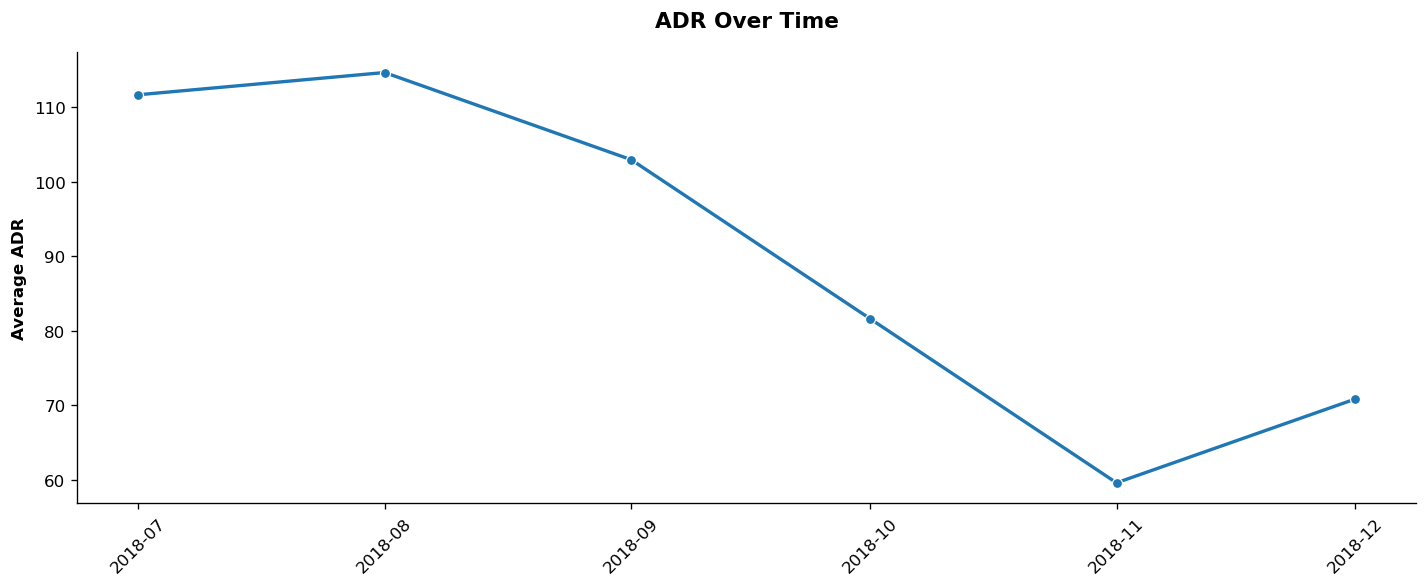

In [18]:
#average ADR by month line chart

monthly_trend = clean_df.groupby(clean_df['arrival_date'].dt.to_period('M'))['adr'].mean().reset_index()
monthly_trend['arrival_date'] = monthly_trend['arrival_date'].dt.to_timestamp()

plt.figure(figsize=(12, 5), dpi=120)
sns.lineplot(data=monthly_trend, x='arrival_date', y='adr', marker='o', linewidth=2)

sns.despine(top=True, right=True)
plt.title("ADR Over Time", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("", fontsize=10, fontweight="bold")
plt.ylabel("Average ADR", fontsize=10, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

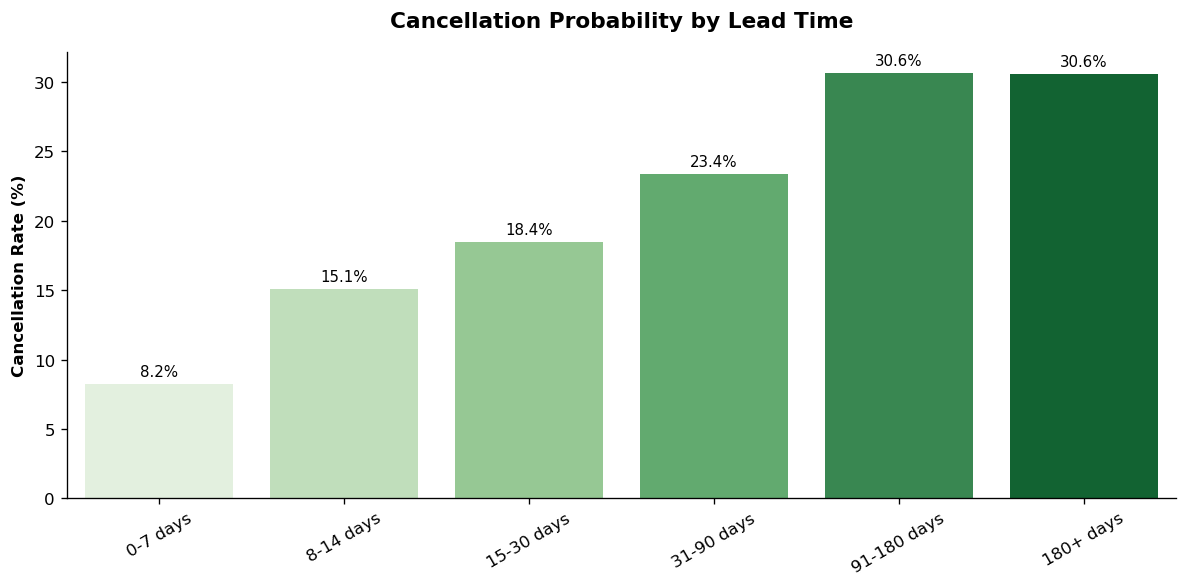

In [10]:
#Cancellation Probability by Lead Time bar chart

#bins & labels
bins = [-1, 7, 14, 30, 90, 180, float("inf")]
labels = [
    "0-7 days",
    "8-14 days",
    "15-30 days",
    "31-90 days",
    "91-180 days",
    "180+ days",
]

clean_df["lead_time_bin"] = pd.cut(
    clean_df["lead_time"], bins=bins, labels=labels
)

#calculations
cancel_trend = (
    clean_df.groupby("lead_time_bin", observed=False)["is_cancelled"]
    .mean()
    .reset_index()
)
cancel_trend["cancellation_rate"] = cancel_trend["is_cancelled"] * 100

#format&color
plt.figure(figsize=(10, 5), dpi=120)

ax = sns.barplot(
    data=cancel_trend,
    x="lead_time_bin",
    y="cancellation_rate",
    hue="lead_time_bin",
    palette="Greens",  # Change palette here (e.g., 'viridis', 'mako', 'crest', 'Purples')
    legend=False,
)

#top of bars labelling
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

#chart shape & labels
sns.despine(top=True, right=True)
plt.title(
    "Cancellation Probability by Lead Time", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("", fontsize=10, fontweight="bold")
plt.ylabel("Cancellation Rate (%)", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

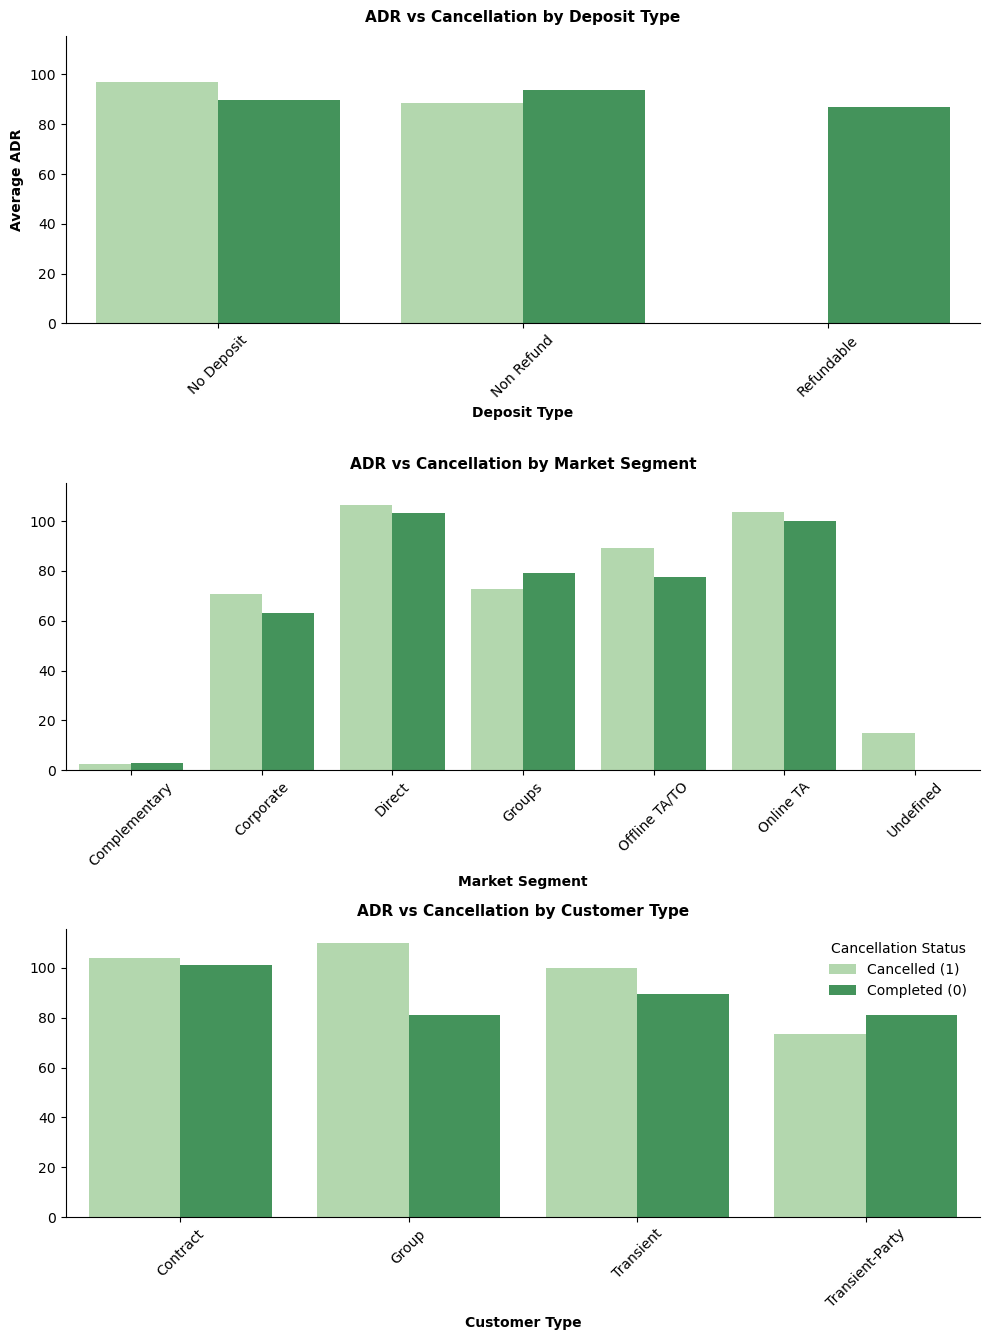

In [48]:
#ADR & cancellation rates, broken down by guest types


def map_cancel(val):
    if val in [1, 1.0, '1', 'True', True, 'Cancelled', 'Cancelled']:
        return 'Cancelled (1)'
    return 'Completed (0)'

clean_df["cancel_status_label"] = clean_df['is_cancelled'].apply(map_cancel)

# variables
variables = ["deposit_type", "market_segment", "customer_type"]
active_vars = [var for var in variables if var in clean_df.columns]


fig, axes = plt.subplots(
    len(active_vars), 1, figsize=(10, 4.5 * len(active_vars)), sharey=True
)

if len(active_vars) == 1:
  axes = [axes]

for i, var in enumerate(active_vars):
    # Group by the specific variable and cancellation status label
    summary_df = (
        clean_df.groupby([var, "cancel_status_label"], observed=False)
        .agg(avg_adr=("adr", "mean"))
        .reset_index()
    )

    #legend (last plot)
    show_legend = (i == len(active_vars) - 1)

    # grouped bar chart
    sns.barplot(
        data=summary_df,
        x=var,
        y="avg_adr",
        hue="cancel_status_label",
        palette="Greens",
        ax=axes[i],
        legend=show_legend
    )

    # Styling
    axes[i].set_title(
        f"ADR vs Cancellation by {var.replace('_', ' ').title()}",
        fontsize=11,
        fontweight="bold",
        pad=10,
    )
    axes[i].set_xlabel(
        var.replace("_", " ").title(), fontsize=10, fontweight="bold"
    )
    axes[i].set_ylabel("Average ADR" if i == 0 else "", fontsize=10, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45)
    
    if show_legend:
        handles, labels = axes[i].get_legend_handles_labels()
        if handles:
            axes[i].legend(handles=handles, labels=labels, title="Cancellation Status", frameon=False, loc="upper right")

    sns.despine(ax=axes[i], top=True, right=True)

plt.tight_layout()
plt.show()

In [47]:
from IPython.display import HTML, display

html_content = """

    
    <div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 20px 24px; border-radius: 10px; color: white; margin-bottom: 20px;">
        <h1 style="margin: 0 0 6px 0; color: #ffffff; font-size: 22px; font-weight: 800; border-bottom: none; padding: 0;">Revenue Conclusions</h1>
        <div style="font-size: 13px; color: #white; opacity: 0.95; line-height: 1.5;">The most informative insights here lie in comparing the ADR between cancelled and completed stays alongside the 
        breakdown of refundable, non refundable, and no deposit bookings. Comparing the ADR of completed versus cancelled stays reveals secured versus potential revenue lost, while also helping to 
        calculate cancellation fees retained. Digging further into cancelled bookings, non-refundable deposits keep a portion of revenue in the event of a cancellation, whereas refundable and no 
        deposit bookings help to accurately measure financial loss.
        
        </div>
    </div>
</div>
"""

display(HTML(html_content))